# 0. Importaciones

In [1]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import kagglehub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Reproducibilidad
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

# Parámetros globales
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 9
EPOCHS = 30

# 1. Carga de datos

In [ ]:
import pathlib

# Buscar la raíz del proyecto (contiene data.dvc) desde el directorio actual
_cwd = pathlib.Path().resolve()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents) if (p / "realwaste.dvc").exists()),
    _cwd
)
path = str(_root / "realwaste")

categories = sorted(os.listdir(path))
rows = []
for category in categories:
    category_dir = os.path.join(path, category)
    for img_name in os.listdir(category_dir):
        rows.append({'image_path': os.path.join(category_dir, img_name), 'label': category})

df = pd.DataFrame(rows)
print(f"Total de imágenes: {len(df)}")
print(f"Clases ({df['label'].nunique()}): {categories}")

Using Colab cache for faster access to the 'real-waste' dataset.
Total de imágenes: 4751
Clases (9): ['1-Cardboard', '2-Food Organics', '3-Glass', '4-Metal', '5-Miscellaneous Trash', '6-Paper', '7-Plastic', '8-Textile Trash', '9-Vegetation']


## 1.1 División en entrenamiento-validación-prueba

In [4]:
# Mapeo de etiquetas a índices numéricos
label_to_index = {label: i for i, label in enumerate(categories)}
print("Mapeo de etiquetas:", label_to_index)

# Partición estratificada 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

print(f"\nEntrenamiento : {len(train_df)} imágenes")
print(f"Validación    : {len(val_df)} imágenes")
print(f"Prueba        : {len(test_df)} imágenes")

Mapeo de etiquetas: {'1-Cardboard': 0, '2-Food Organics': 1, '3-Glass': 2, '4-Metal': 3, '5-Miscellaneous Trash': 4, '6-Paper': 5, '7-Plastic': 6, '8-Textile Trash': 7, '9-Vegetation': 8}

Entrenamiento : 3325 imágenes
Validación    : 713 imágenes
Prueba        : 713 imágenes


## 1.2 Tratamiento del Desbalance de clases

In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Calcular pesos de clase para compensar el desbalance
train_labels = train_df['label'].map(label_to_index).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("Pesos por clase:")
for label, idx in sorted(label_to_index.items(), key=lambda x: x[1]):
    print(f"  {label:25s} (clase {idx}): {class_weight_dict[idx]:.4f}")

Pesos por clase:
  1-Cardboard               (clase 0): 1.1473
  2-Food Organics           (clase 1): 1.2828
  3-Glass                   (clase 2): 1.2566
  4-Metal                   (clase 3): 0.6681
  5-Miscellaneous Trash     (clase 4): 1.0678
  6-Paper                   (clase 5): 1.0556
  7-Plastic                 (clase 6): 0.5728
  8-Textile Trash           (clase 7): 1.6642
  9-Vegetation              (clase 8): 1.2113


In [6]:
def load_and_preprocess(image_path, label):
    """Lee una imagen desde disco, la redimensiona y normaliza a [0, 1]."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def build_dataset(dataframe, shuffle=True):
    """Construye un tf.data.Dataset a partir de un DataFrame con columnas image_path y label."""
    paths = dataframe['image_path'].values
    labels = dataframe['label'].map(label_to_index).values
    labels = tf.keras.utils.to_categorical(labels, NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1024, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Construcción de los pipelines
train_ds = build_dataset(train_df, shuffle=True)
val_ds   = build_dataset(val_df, shuffle=False)
test_ds  = build_dataset(test_df, shuffle=False)

# Verificación rápida
for images, labels in train_ds.take(1):
    print(f"Forma del lote de imágenes : {images.shape}")
    print(f"Forma del lote de etiquetas: {labels.shape}")

Forma del lote de imágenes : (32, 224, 224, 3)
Forma del lote de etiquetas: (32, 9)


## 2. Arquitectura del modelo base

In [7]:
class WasteClassifierCNN:
    """
    CNN configurable para clasificación de residuos RealWaste.

    Parámetros ajustables (hiperparámetros):
        input_shape      : dimensiones de entrada (alto, ancho, canales).
        num_classes      : número de clases de salida.
        filters          : tupla con el número de filtros por bloque convolucional.
        kernel_size      : tamaño del kernel en las capas Conv2D.
        pool_size        : tamaño de ventana de MaxPooling2D.
        dense_units      : tupla con las unidades de cada capa densa del clasificador.
        dropout_rate     : tasa de dropout después de cada capa densa.
        use_batch_norm   : si se aplica Batch Normalization tras cada convolución.
        use_augmentation : si se incluyen capas de aumentación de datos.
        learning_rate    : tasa de aprendizaje del optimizador Adam.
    """

    DEFAULT_PARAMS = dict(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=NUM_CLASSES,
        filters=(32, 64, 128, 256),
        kernel_size=3,
        pool_size=2,
        dense_units=(512,256),
        dropout_rate=0.2,
        use_batch_norm=True,
        use_augmentation=True,
        learning_rate=1e-3,
    )

    def __init__(self, **kwargs):
        self.params = {**self.DEFAULT_PARAMS, **kwargs}
        self.model = self._build()
        self.history = None

    # ------------------------------------------------------------------ #
    #  Construcción del modelo (Functional API)                           #
    # ------------------------------------------------------------------ #
    def _build(self):
        p = self.params
        inputs = keras.Input(shape=p['input_shape'], name='input_image')
        x = inputs

        # --- Aumentación de datos (solo activa en training) ---
        if p['use_augmentation']:
            x = keras.layers.RandomFlip('horizontal')(x)
            x = keras.layers.RandomRotation(0.15)(x)
            x = keras.layers.RandomZoom(0.2)(x)

        # --- Bloques convolucionales ---
        for i, f in enumerate(p['filters']):
            x = keras.layers.Conv2D(f, p['kernel_size'], padding='same',
                                    name=f'conv{i+1}_a')(x)
            if p['use_batch_norm']:
                x = keras.layers.BatchNormalization(name=f'bn{i+1}_a')(x)
            x = keras.layers.Activation('relu')(x)

            x = keras.layers.Conv2D(f, p['kernel_size'], padding='same',
                                    name=f'conv{i+1}_b')(x)
            if p['use_batch_norm']:
                x = keras.layers.BatchNormalization(name=f'bn{i+1}_b')(x)
            x = keras.layers.Activation('relu')(x)

            x = keras.layers.MaxPooling2D(p['pool_size'], name=f'pool{i+1}')(x)

        # --- Clasificador ---
        x = keras.layers.GlobalAveragePooling2D(name='gap')(x)

        for j, units in enumerate(p['dense_units']):
            x = keras.layers.Dense(units, activation='relu',
                                   name=f'dense{j+1}')(x)
            if p['dropout_rate'] > 0:
                x = keras.layers.Dropout(p['dropout_rate'],
                                         name=f'dropout{j+1}')(x)

        outputs = keras.layers.Dense(p['num_classes'], activation='softmax',
                                     name='predictions')(x)

        model = keras.Model(inputs, outputs, name='WasteClassifierCNN')
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=p['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    # ------------------------------------------------------------------ #
    #  Entrenamiento                                                      #
    # ------------------------------------------------------------------ #
    def fit(self, train_ds, val_ds, epochs=30, patience=5, verbose=1,
            class_weight=None):
        """Entrena el modelo con Early Stopping sobre val_accuracy.

        Parameters
        ----------
        class_weight : dict | None
            Diccionario {índice_clase: peso} para compensar desbalance de clases.
        """
        callbacks = [
            keras.callbacks.ModelCheckpoint(
                'best_model.keras',
                monitor='val_accuracy',
                save_best_only=True,
                verbose=1
            ),
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=patience,
                restore_best_weights=True,
                verbose=1,
            ),
        ]
        self.history = self.model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=verbose,
        )
        return self.history

    # ------------------------------------------------------------------ #
    #  Evaluación                                                         #
    # ------------------------------------------------------------------ #
    def evaluate(self, test_ds):
        """Evalúa el modelo sobre un conjunto de prueba."""
        return self.model.evaluate(test_ds, verbose=1)

    def summary(self):
        return self.model.summary()

    # ------------------------------------------------------------------ #
    #  Búsqueda de hiperparámetros (Grid Search)                         #
    # ------------------------------------------------------------------ #
    @staticmethod
    def grid_search(param_grid, train_ds, val_ds,
                    fixed_params=None, epochs=15, patience=3,
                    class_weight=None):
        """
        Búsqueda exhaustiva de hiperparámetros.

        Parámetros
        ----------
        param_grid   : dict[str, list]
            Diccionario con los hiperparámetros y sus valores a explorar.
            Ejemplo: {'filters': [(32,64), (64,128,256)], 'dropout_rate': [0.3, 0.5]}
        train_ds     : tf.data.Dataset de entrenamiento.
        val_ds       : tf.data.Dataset de validación.
        fixed_params : dict | None
            Parámetros fijos que no se varían en la búsqueda.
        epochs       : int   — épocas máximas por configuración.
        patience     : int   — paciencia del early stopping.
        class_weight : dict | None
            Pesos de clase para compensar desbalance.

        Retorna
        -------
        pd.DataFrame con los resultados ordenados por val_accuracy descendente.
        """
        fixed = fixed_params or {}
        keys = list(param_grid.keys())
        combos = list(itertools.product(*param_grid.values()))
        results = []

        print(f"Grid Search — {len(combos)} combinaciones a evaluar\n")
        for idx, values in enumerate(combos, 1):
            hp = {**fixed, **dict(zip(keys, values))}
            tag = ', '.join(f'{k}={v}' for k, v in zip(keys, values))
            print(f"[{idx}/{len(combos)}] {tag}")

            clf = WasteClassifierCNN(**hp)
            clf.fit(train_ds, val_ds, epochs=epochs,
                    patience=patience, verbose=0,
                    class_weight=class_weight)

            best_val_acc  = max(clf.history.history['val_accuracy'])
            best_val_loss = min(clf.history.history['val_loss'])
            n_epochs_run  = len(clf.history.history['val_accuracy'])

            results.append({
                **dict(zip(keys, values)),
                'val_accuracy': round(best_val_acc, 4),
                'val_loss': round(best_val_loss, 4),
                'epochs_run': n_epochs_run,
            })
            print(f"   → val_accuracy={best_val_acc:.4f}  "
                  f"val_loss={best_val_loss:.4f}  "
                  f"épocas={n_epochs_run}\n")

            del clf
            tf.keras.backend.clear_session()

        results_df = pd.DataFrame(results) \
                       .sort_values('val_accuracy', ascending=False) \
                       .reset_index(drop=True)
        return results_df

# 3. Entrenamiento con mejores hiperparámetros

El conjunto de mejores hiperparámetros se obtuvo de un proceso de búsqueda previamente realizado en un etapa preliminar de este proyecto. Por tanto, es considerado como el modelo base para el trabajo en curso.

Para la evaluación del modelo base, y considerando que ya se tiene el mejor conjunto de hiperparámetros, se unen los conjuntos de entrenamiento y validación originales para darle al modelo la mayor cantidad de datos posible durante su entrenamiento, aplicando únicamente un 10% de los datos para validación durante el proceso de entrenamiento. De esta forma, se obtienen los parámetros finales del modelo base, que serán utilizados como referencia para comparar con los modelos que se desarrollarán posteriormente.

In [8]:
# Unir train y val originales
full_train_df = pd.concat([train_df, val_df], ignore_index=True)

# Separar 10% para validación, estratificando por clase
new_train_df, new_val_df = train_test_split(
    full_train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=full_train_df['label']  
)

# Reset de índices
new_train_df = new_train_df.reset_index(drop=True)
new_val_df   = new_val_df.reset_index(drop=True)

print(f"Train final : {len(new_train_df)} imágenes")
print(f"Val final   : {len(new_val_df)} imágenes")

# 3. Construir los datasets
new_train_ds = build_dataset(new_train_df, shuffle=True)
new_val_ds   = build_dataset(new_val_df,   shuffle=False)

Train final : 3634 imágenes
Val final   : 404 imágenes


In [9]:
best_params = {'filters': (32, 64, 128),
              'dense_units': (512, 256),
              'dropout_rate': 0.2,
              'learning_rate': 0.001}
baseline = WasteClassifierCNN(**best_params)
baseline.summary()

Model: "WasteClassifierCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_a (Conv2D)                │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_a (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_b (Conv2D)                │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_b (BatchNormalization)      │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_a (Conv2D)                │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_a (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_b (Conv2D)                │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_b (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_a (Conv2D)                │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_a (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_b (Conv2D)                │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_b (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 488,489 (1.86 MB)

 Trainable params: 487,593 (1.86 MB)

 Non-trainable params: 896 (3.50 KB)

In [10]:
baseline.fit(new_train_ds, new_val_ds, epochs=50, patience=15, class_weight=class_weight_dict)

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.3353 - loss: 1.7192
Epoch 1: val_accuracy improved from None to 0.08911, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 51s 296ms/step - accuracy: 0.4037 - loss: 1.5583 - val_accuracy: 0.0891 - val_loss: 6.3067
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.4769 - loss: 1.3709
Epoch 2: val_accuracy improved from 0.08911 to 0.09406, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.4865 - loss: 1.3401 - val_accuracy: 0.0941 - val_loss: 3.9250
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5054 - loss: 1.2773
Epoch 3: val_accuracy did not improve from 0.09406
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 273ms/step - accuracy: 0.5154 - loss: 1.2634 - val_accuracy: 0.0916 - val_loss: 8.5415
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 267

## 4. Evaluación del modelo base

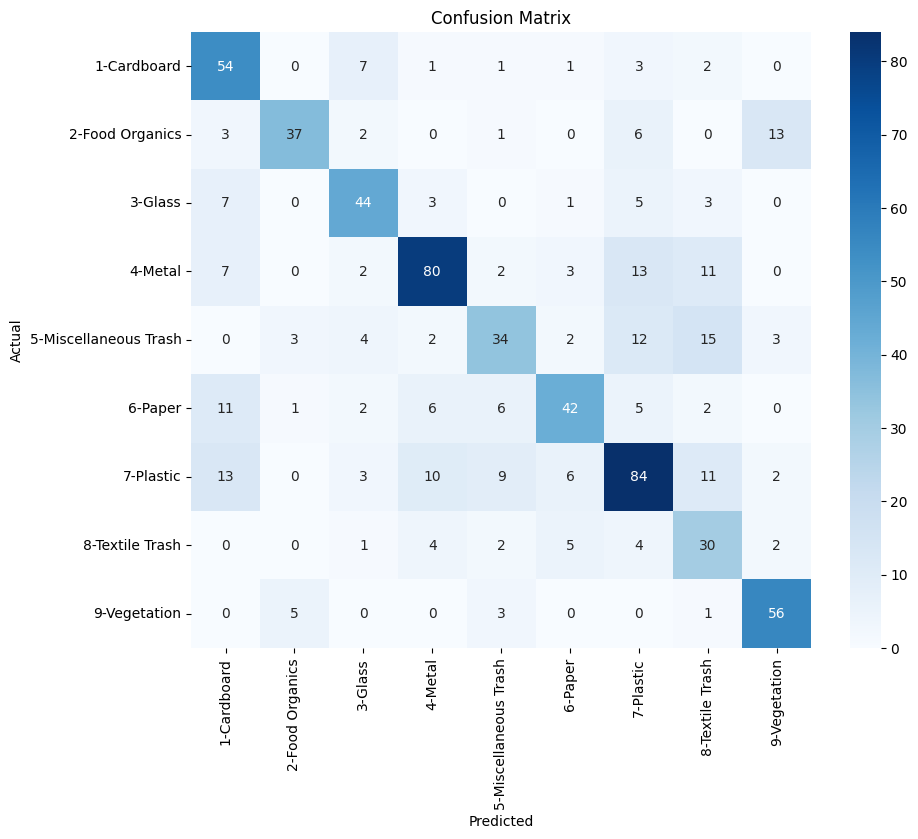

In [11]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = baseline.model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

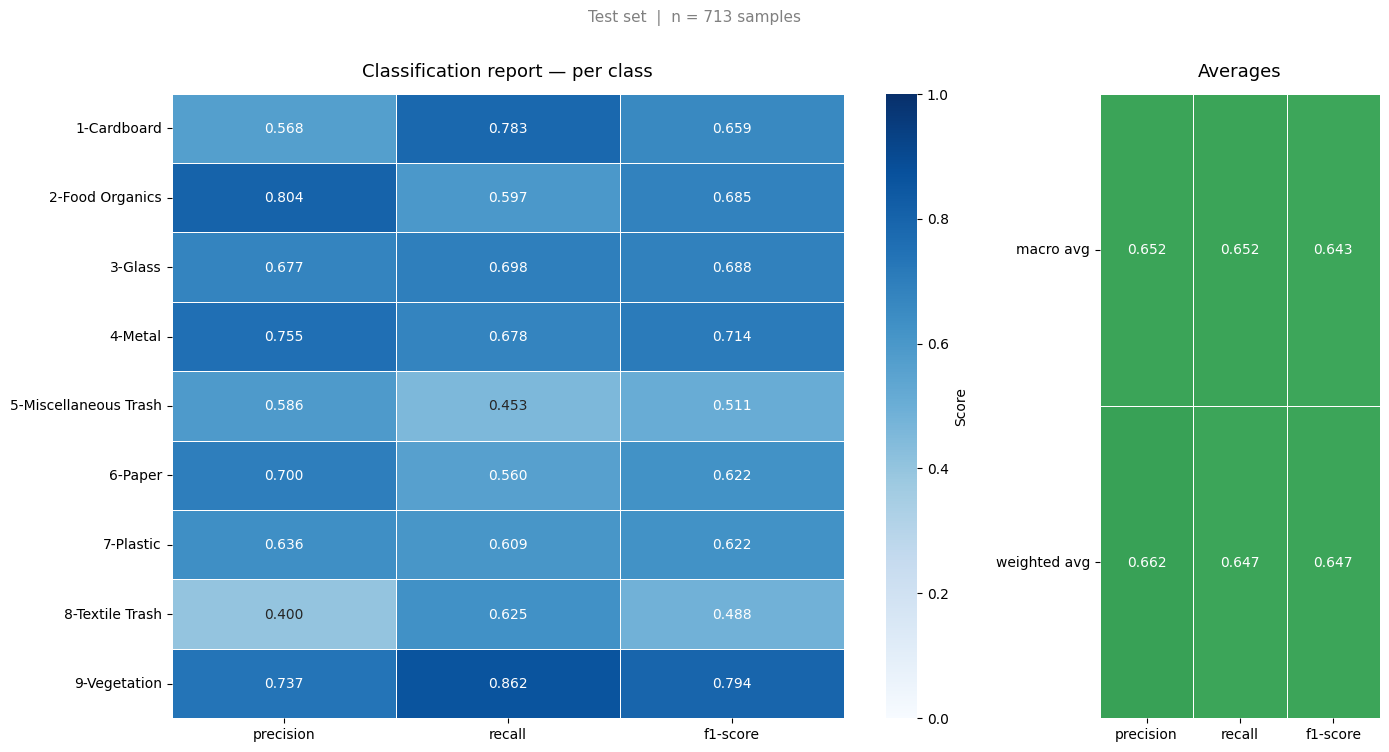

In [12]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = baseline.model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Convertir el report a DataFrame
report_dict = classification_report(
    y_true, y_pred,
    target_names=categories,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T

# Separar las métricas por clase de los promedios
metrics_df   = report_df.loc[categories, ['precision', 'recall', 'f1-score']]
averages_df  = report_df.loc[['macro avg', 'weighted avg'], ['precision', 'recall', 'f1-score']]

fig, axes = plt.subplots(1, 2, figsize=(14, len(categories) * 0.6 + 2),
                         gridspec_kw={'width_ratios': [3, 1]})

# Heatmap principal — métricas por clase
sns.heatmap(
    metrics_df.astype(float),
    ax=axes[0],
    annot=True, fmt='.3f',
    cmap='Blues',
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)
axes[0].set_title('Classification report — per class', fontsize=13, pad=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# Heatmap secundario — promedios
sns.heatmap(
    averages_df.astype(float),
    ax=axes[1],
    annot=True, fmt='.3f',
    cmap='Greens',
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar=False
)
axes[1].set_title('Averages', fontsize=13, pad=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'Test set  |  n = {len(y_true)} samples', fontsize=11,
             color='gray', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Overall accuracy
overall_acc = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Overall accuracy: {overall_acc:.4f}")

Overall accuracy: 0.6466
